# AI Startup Success Predictor using Machine Learning

## Machine Learning Mini Project

**Student Name:** Your Name

**Course:** Machine Learning

**Project Title:** AI Startup Success Predictor using Machine Learning

In [89]:
# Importing required libraries

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [90]:
# Load the dataset

df = pd.read_csv("startup.csv")

In [91]:
df.head()

,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,1005,CA,42.358880,-71.056820,92101,c:6669,San Diego,NaN,Bandsintown,1,...,c:6669,0,1,0,0,0,0,1.0000,0,acquired
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,...,c:16283,1,0,0,1,1,1,4.7500,1,acquired
2,1001,CA,32.901049,-117.192656,92121,c:65620,San Diego,San Diego CA 92121,Plixi,1,...,c:65620,0,0,1,0,0,0,4.0000,1,acquired
3,738,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Cupertino CA 95014,Solidcore Systems,1,...,c:42668,0,0,0,1,1,1,3.3333,1,acquired
4,1002,CA,37.779281,-122.419236,94105,c:65806,San Francisco,San Francisco CA 94105,Inhale Digital,0,...,c:65806,1,1,0,0,0,0,1.0000,1,closed


In [92]:
df.tail()

,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
918,352,CA,37.740594,-122.376471,94107,c:21343,San Francisco,NaN,CoTweet,1,...,c:21343,0,0,1,0,0,0,6.0000,1,acquired
919,721,MA,42.504817,-71.195611,1803,c:41747,Burlington,Burlington MA 1803,Reef Point Systems,0,...,c:41747,1,0,0,1,0,0,2.6667,1,closed
920,557,CA,37.408261,-122.015920,94089,c:31549,Sunnyvale,NaN,Paracor Medical,0,...,c:31549,0,0,0,0,0,1,8.0000,1,closed
921,589,CA,37.556732,-122.288378,94404,c:33198,San Francisco,NaN,Causata,1,...,c:33198,0,0,1,1,0,0,1.0000,1,acquired
922,462,CA,37.386778,-121.966277,95054,c:26702,Santa Clara,Santa Clara CA 95054,Asempra Technologies,1,...,c:26702,0,0,0,1,0,0,3.0000,1,acquired


In [93]:
df.shape

(923, 49)

In [94]:
df.columns

Index(['Unnamed: 0', 'state_code', 'latitude', 'longitude', 'zip_code', 'id',
       'city', 'Unnamed: 6', 'name', 'labels', 'founded_at', 'closed_at',
       'first_funding_at', 'last_funding_at', 'age_first_funding_year',
       'age_last_funding_year', 'age_first_milestone_year',
       'age_last_milestone_year', 'relationships', 'funding_rounds',
       'funding_total_usd', 'milestones', 'state_code.1', 'is_CA', 'is_NY',
       'is_MA', 'is_TX', 'is_otherstate', 'category_code', 'is_software',
       'is_web', 'is_mobile', 'is_enterprise', 'is_advertising',
       'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting',
       'is_othercategory', 'object_id', 'has_VC', 'has_angel', 'has_roundA',
       'has_roundB', 'has_roundC', 'has_roundD', 'avg_participants',
       'is_top500', 'status'],
      dtype='str')

In [95]:
df.dtypes

Unnamed: 0                    int64
state_code                      str
latitude                    float64
longitude                   float64
zip_code                        str
id                              str
city                            str
Unnamed: 6                      str
name                            str
labels                        int64
founded_at                      str
closed_at                       str
first_funding_at                str
last_funding_at                 str
age_first_funding_year      float64
age_last_funding_year       float64
age_first_milestone_year    float64
age_last_milestone_year     float64
relationships                 int64
funding_rounds                int64
funding_total_usd             int64
milestones                    int64
state_code.1                    str
is_CA                         int64
is_NY                         int64
is_MA                         int64
is_TX                         int64
is_otherstate               

In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                923 non-null    int64  
 1   state_code                923 non-null    str    
 2   latitude                  923 non-null    float64
 3   longitude                 923 non-null    float64
 4   zip_code                  923 non-null    str    
 5   id                        923 non-null    str    
 6   city                      923 non-null    str    
 7   Unnamed: 6                430 non-null    str    
 8   name                      923 non-null    str    
 9   labels                    923 non-null    int64  
 10  founded_at                923 non-null    str    
 11  closed_at                 335 non-null    str    
 12  first_funding_at          923 non-null    str    
 13  last_funding_at           923 non-null    str    
 14  age_first_funding_yea

In [97]:
df.describe()

,Unnamed: 0,latitude,longitude,labels,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,...,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,771.000000,771.000000,923.000000,923.000000,...,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,572.297941,38.517442,-103.539212,0.646804,2.235630,3.931456,3.055353,4.754423,7.710726,2.310943,...,0.003250,0.322860,0.326111,0.254605,0.508126,0.392199,0.232936,0.099675,2.838586,0.809317
std,333.585431,3.741497,22.394167,0.478222,2.510449,2.967910,2.977057,3.212107,7.265776,1.390922,...,0.056949,0.467823,0.469042,0.435875,0.500205,0.488505,0.422931,0.299729,1.874601,0.393052
min,1.000000,25.752358,-122.756956,0.000000,-9.046600,-9.046600,-14.169900,-7.005500,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,283.500000,37.388869,-122.198732,0.000000,0.576700,1.669850,1.000000,2.411000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,1.000000
50%,577.000000,37.779281,-118.374037,1.000000,1.446600,3.528800,2.520500,4.476700,5.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.500000,1.000000
75%,866.500000,40.730646,-77.214731,1.000000,3.575350,5.560250,4.686300,6.753400,10.000000,3.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,3.800000,1.000000
max,1153.000000,59.335232,18.057121,1.000000,21.895900,21.895900,24.684900,24.684900,63.000000,10.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,16.000000,1.000000


Data Understanding

In [98]:
print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (923, 49)
Number of Rows: 923
Number of Columns: 49


In [99]:
print("Columns in Dataset:\n")

for column in df.columns:
    print(column)

Columns in Dataset:

Unnamed: 0
state_code
latitude
longitude
zip_code
id
city
Unnamed: 6
name
labels
founded_at
closed_at
first_funding_at
last_funding_at
age_first_funding_year
age_last_funding_year
age_first_milestone_year
age_last_milestone_year
relationships
funding_rounds
funding_total_usd
milestones
state_code.1
is_CA
is_NY
is_MA
is_TX
is_otherstate
category_code
is_software
is_web
is_mobile
is_enterprise
is_advertising
is_gamesvideo
is_ecommerce
is_biotech
is_consulting
is_othercategory
object_id
has_VC
has_angel
has_roundA
has_roundB
has_roundC
has_roundD
avg_participants
is_top500
status


In [100]:
missing_values = df.isnull().sum()
print(missing_values)

Unnamed: 0                    0
state_code                    0
latitude                      0
longitude                     0
zip_code                      0
id                            0
city                          0
Unnamed: 6                  493
name                          0
labels                        0
founded_at                    0
closed_at                   588
first_funding_at              0
last_funding_at               0
age_first_funding_year        0
age_last_funding_year         0
age_first_milestone_year    152
age_last_milestone_year     152
relationships                 0
funding_rounds                0
funding_total_usd             0
milestones                    0
state_code.1                  1
is_CA                         0
is_NY                         0
is_MA                         0
is_TX                         0
is_otherstate                 0
category_code                 0
is_software                   0
is_web                        0
is_mobil

In [101]:
missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values
})

missing_df

,Column,Missing Values
0,Unnamed: 0,0
1,state_code,0
2,latitude,0
3,longitude,0
4,zip_code,0
5,id,0
6,city,0
7,Unnamed: 6,493
8,name,0
9,labels,0


In [102]:
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [103]:
# Columns to remove

columns_to_drop = [
    "Unnamed: 0",
    "Unnamed: 6",
    "closed_at",
    "state_code.1"
]

df.drop(columns=columns_to_drop, inplace=True)

In [104]:
# Fill missing values using median

df["age_first_milestone_year"] = df["age_first_milestone_year"].fillna(
    df["age_first_milestone_year"].median()
)

df["age_last_milestone_year"] = df["age_last_milestone_year"].fillna(
    df["age_last_milestone_year"].median()
)

In [105]:
print(df.shape)

(923, 45)


## Data Cleaning

The following preprocessing steps were performed:

- Removed duplicate records (none found).
- Removed the Unnamed: 0 column as it represented only row indices.
- Removed Unnamed: 6 because more than 50% of its values were missing.
- Removed 'closed_at' to avoid data leakage, since it contains information available only after startup failure.
- Removed state_code.1 because it 'duplicated the state_code' column.
- Filled missing values in 'age_first_milestone_year' using the median.
- Filled missing values in 'age_last_milestone_year' using the median.

The cleaned dataset is now ready for Exploratory Data Analysis (EDA).

Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the distribution of data, identify patterns, detect outliers, and analyze relationships among variables before training machine learning models.

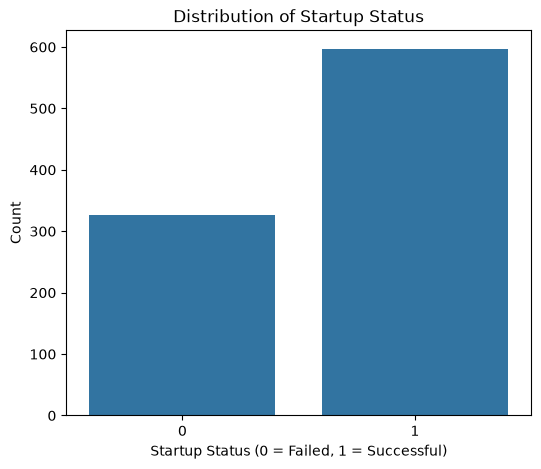

In [106]:
plt.figure(figsize=(6,5))

sns.countplot(x="labels", data=df)

plt.title("Distribution of Startup Status")
plt.xlabel("Startup Status (0 = Failed, 1 = Successful)")
plt.ylabel("Count")

plt.show()

Observation:
- This graph shows the number of successful and failed startups.
- The dataset is reasonably balanced, making it suitable for classification.

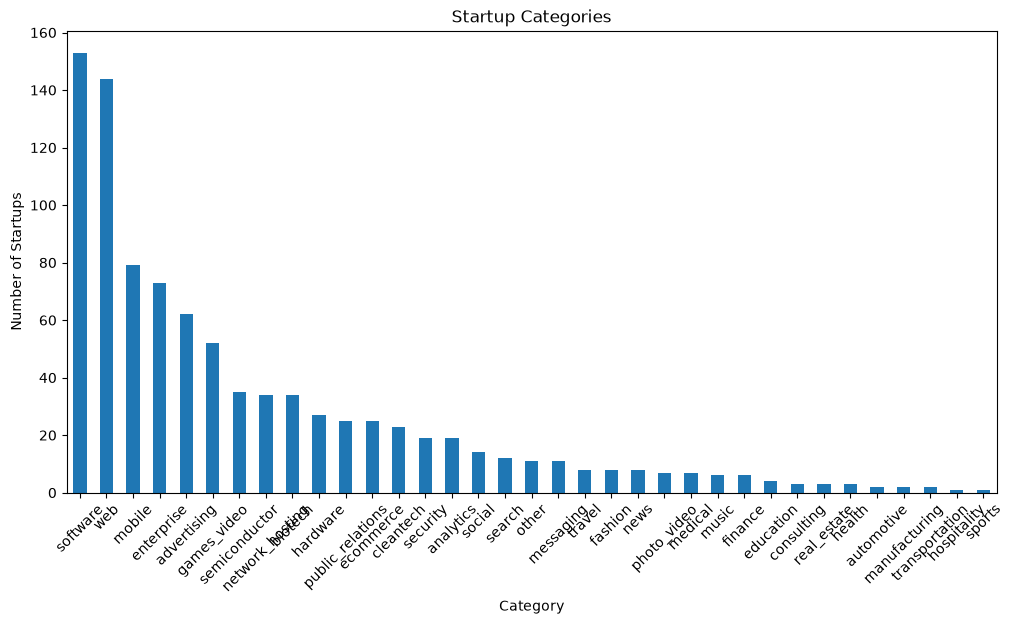

In [107]:
plt.figure(figsize=(12,6))

df["category_code"].value_counts().plot(kind="bar")

plt.title("Startup Categories")
plt.xlabel("Category")
plt.ylabel("Number of Startups")

plt.xticks(rotation=45)

plt.show()

Observation:
- This graph shows which startup sectors are most common.
- Some industries have significantly more startups than others.

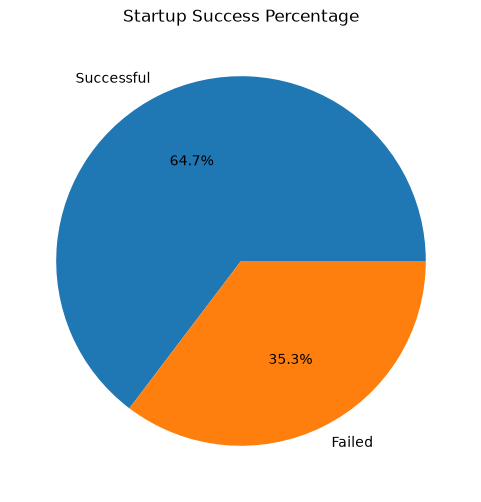

In [108]:
plt.figure(figsize=(6,6))

df["labels"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Successful", "Failed"]
)

plt.ylabel("")

plt.title("Startup Success Percentage")

plt.show()

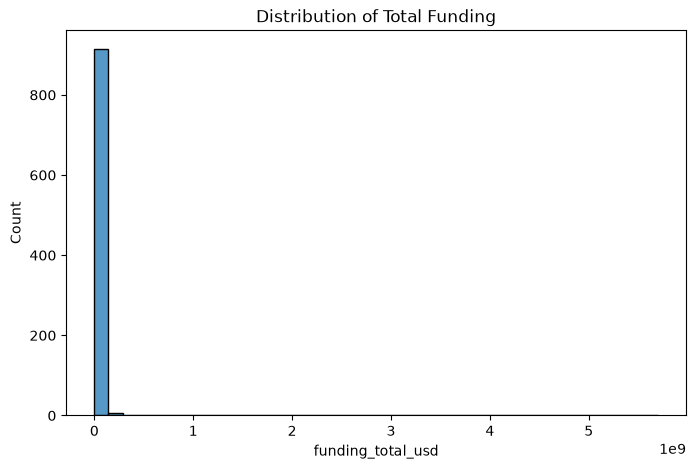

In [109]:
plt.figure(figsize=(8,5))

sns.histplot(df["funding_total_usd"], bins=40)

plt.title("Distribution of Total Funding")

plt.show()

Observation:
- Funding amounts are highly skewed.
- Most startups receive relatively low funding, while a few receive very large investments.

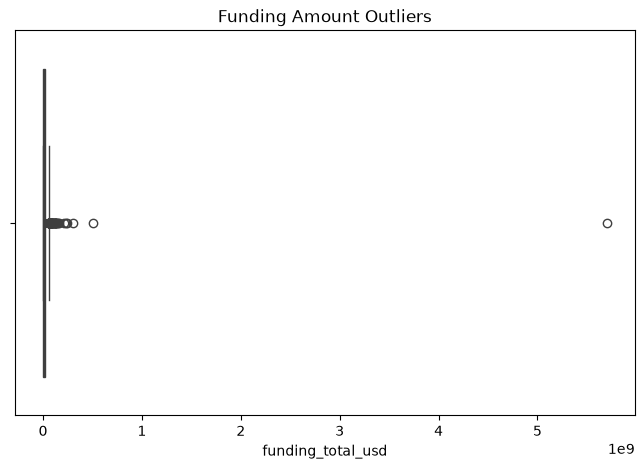

In [110]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["funding_total_usd"])

plt.title("Funding Amount Outliers")

plt.show()

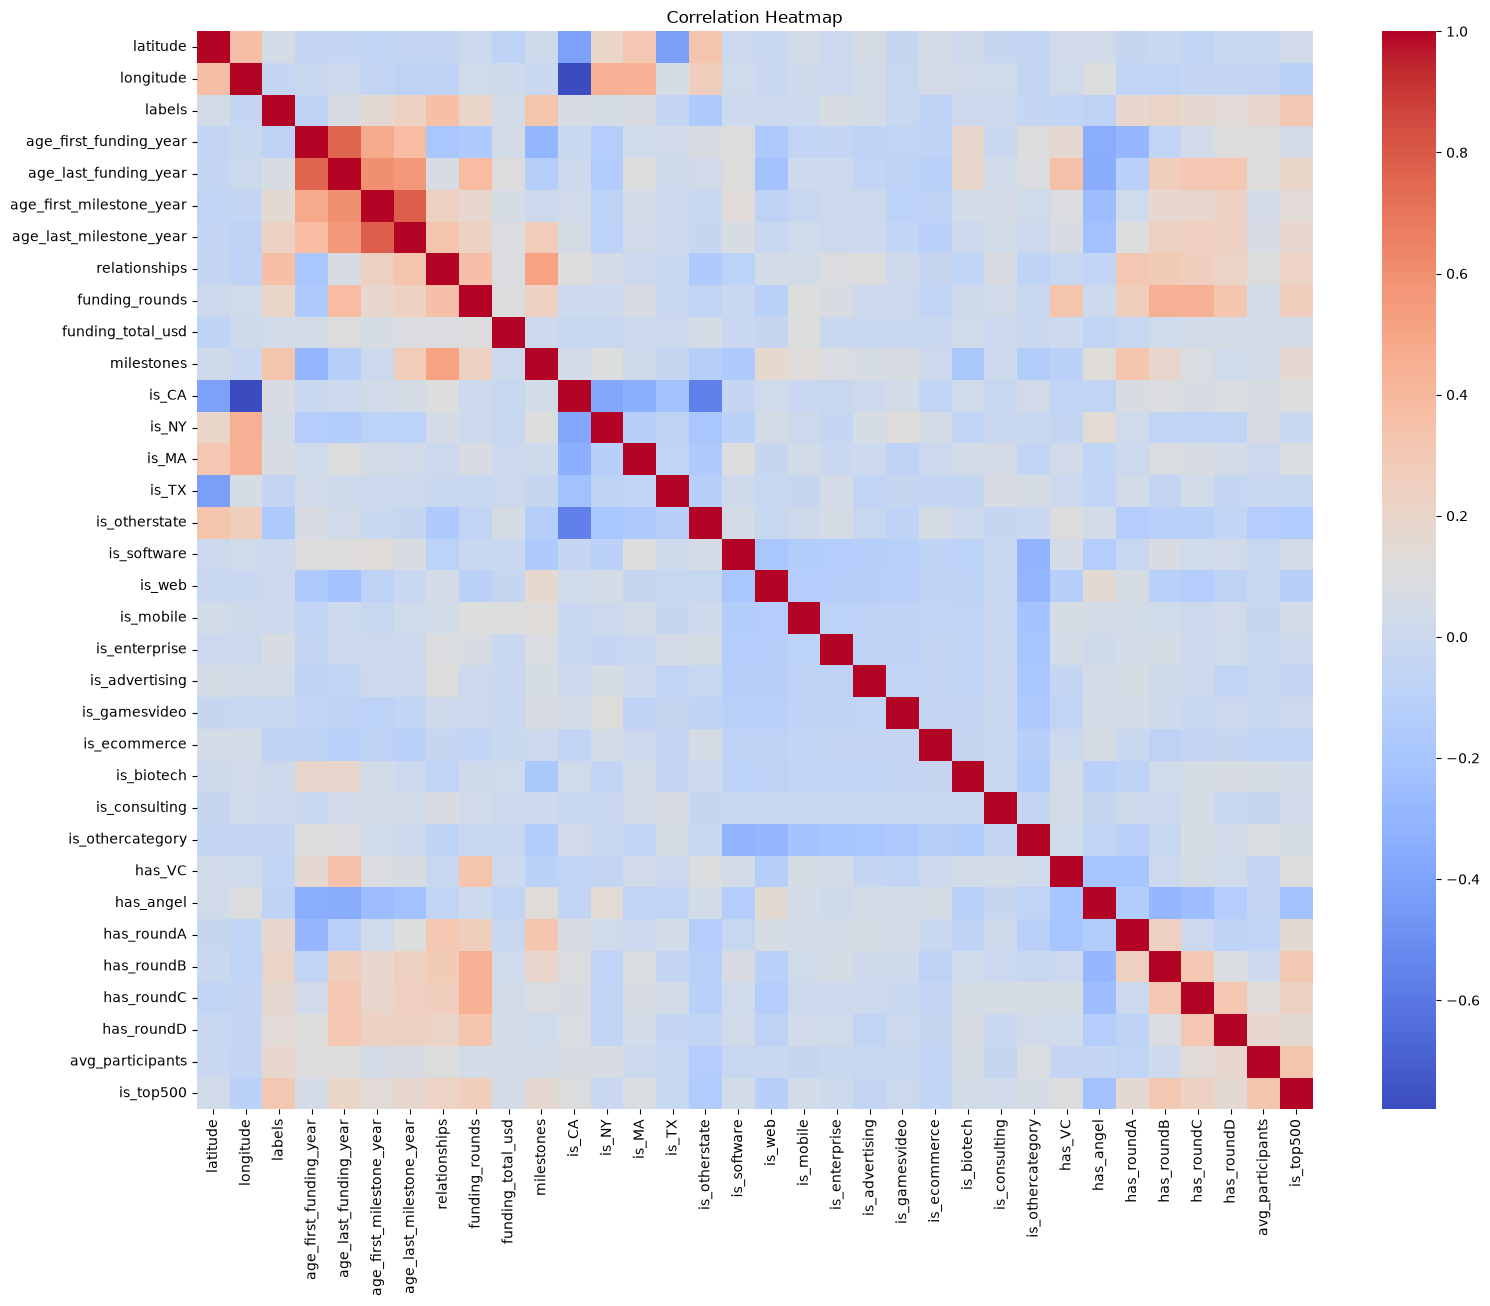

In [111]:
plt.figure(figsize=(18,14))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

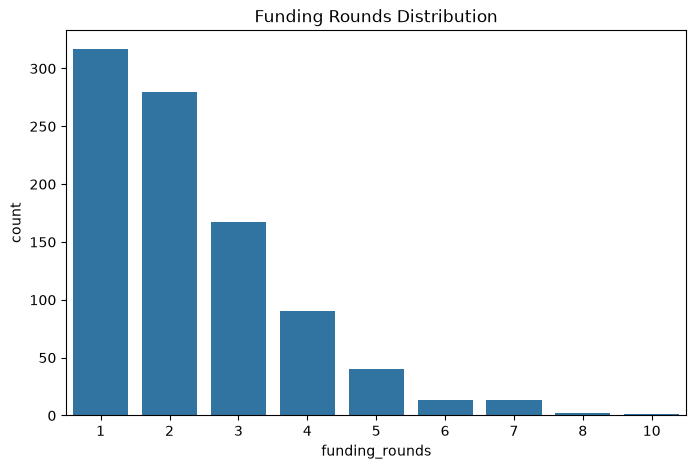

In [112]:
plt.figure(figsize=(8,5))

sns.countplot(x="funding_rounds", data=df)

plt.title("Funding Rounds Distribution")

plt.show()

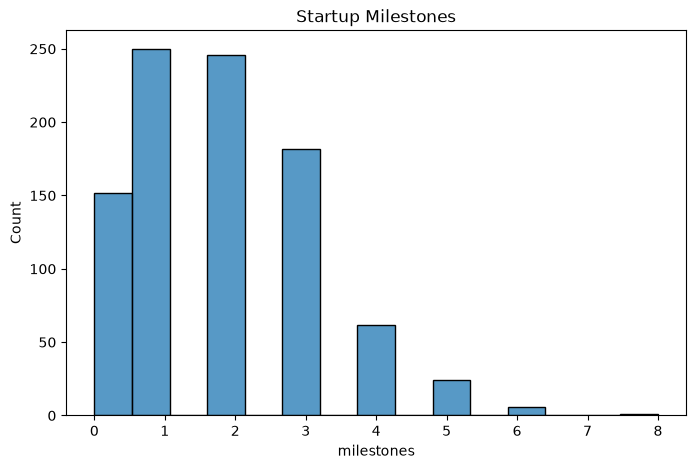

In [113]:
plt.figure(figsize=(8,5))

sns.histplot(df["milestones"], bins=15)

plt.title("Startup Milestones")

plt.show()

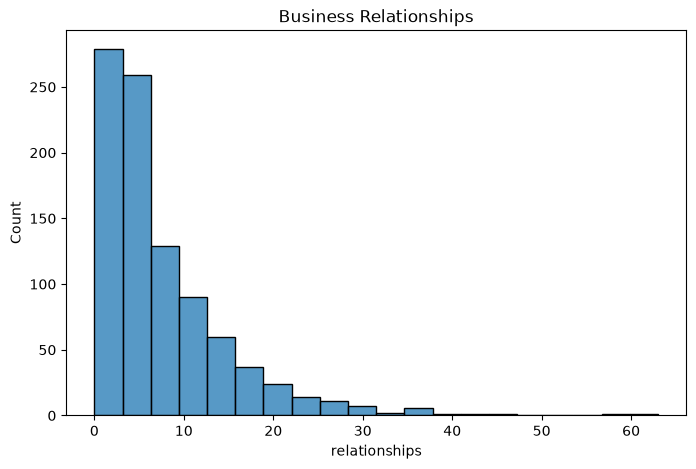

In [114]:
plt.figure(figsize=(8,5))

sns.histplot(df["relationships"], bins=20)

plt.title("Business Relationships")

plt.show()

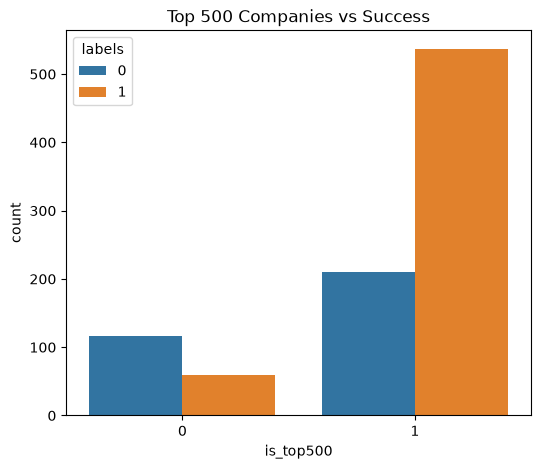

In [115]:
plt.figure(figsize=(6,5))

sns.countplot(x="is_top500", hue="labels", data=df)

plt.title("Top 500 Companies vs Success")

plt.show()

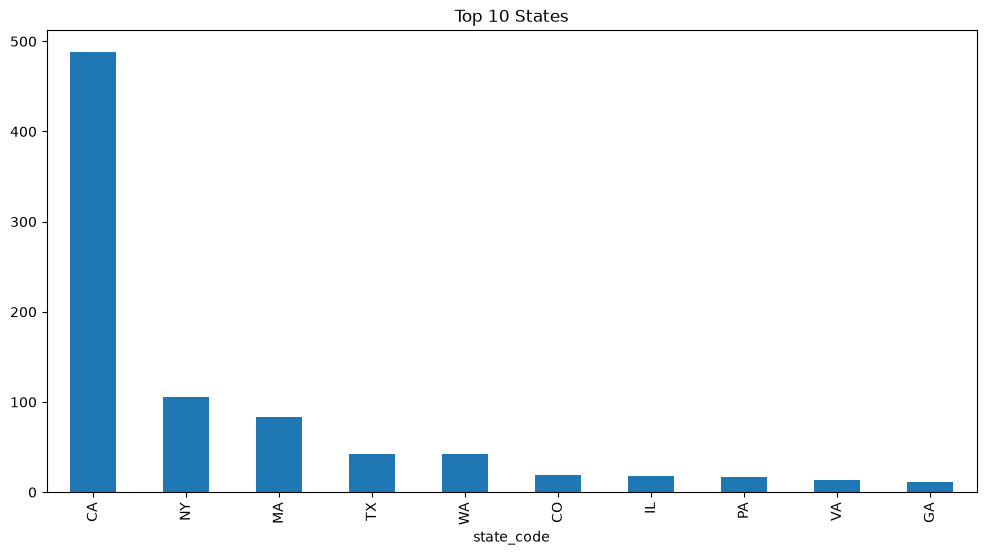

In [116]:
plt.figure(figsize=(12,6))

df["state_code"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 States")

plt.show()

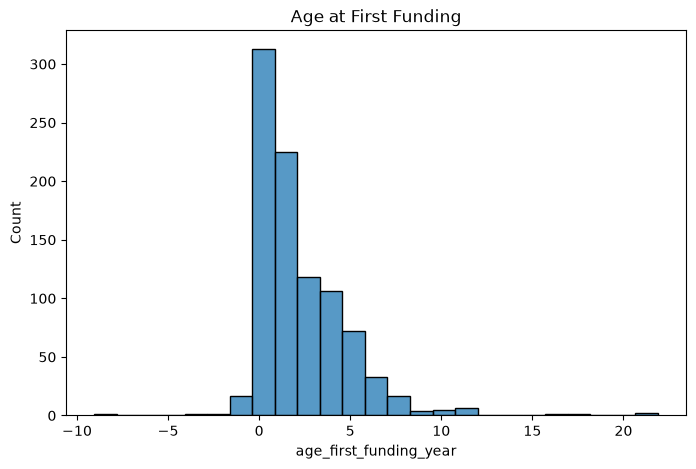

In [117]:
plt.figure(figsize=(8,5))

sns.histplot(df["age_first_funding_year"], bins=25)

plt.title("Age at First Funding")

plt.show()

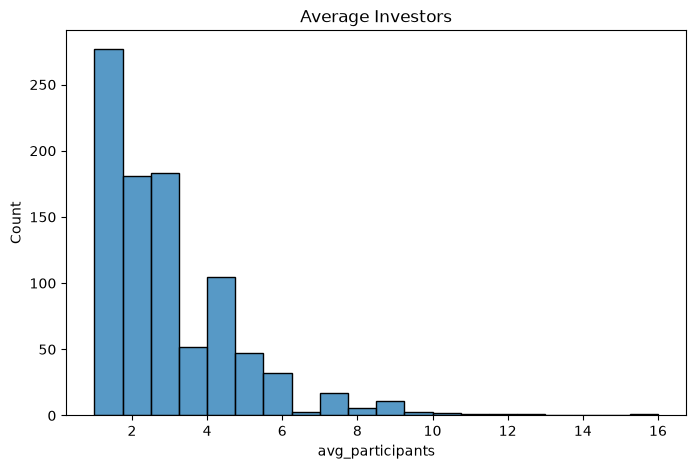

In [118]:
plt.figure(figsize=(8,5))

sns.histplot(df["avg_participants"], bins=20)

plt.title("Average Investors")

plt.show()

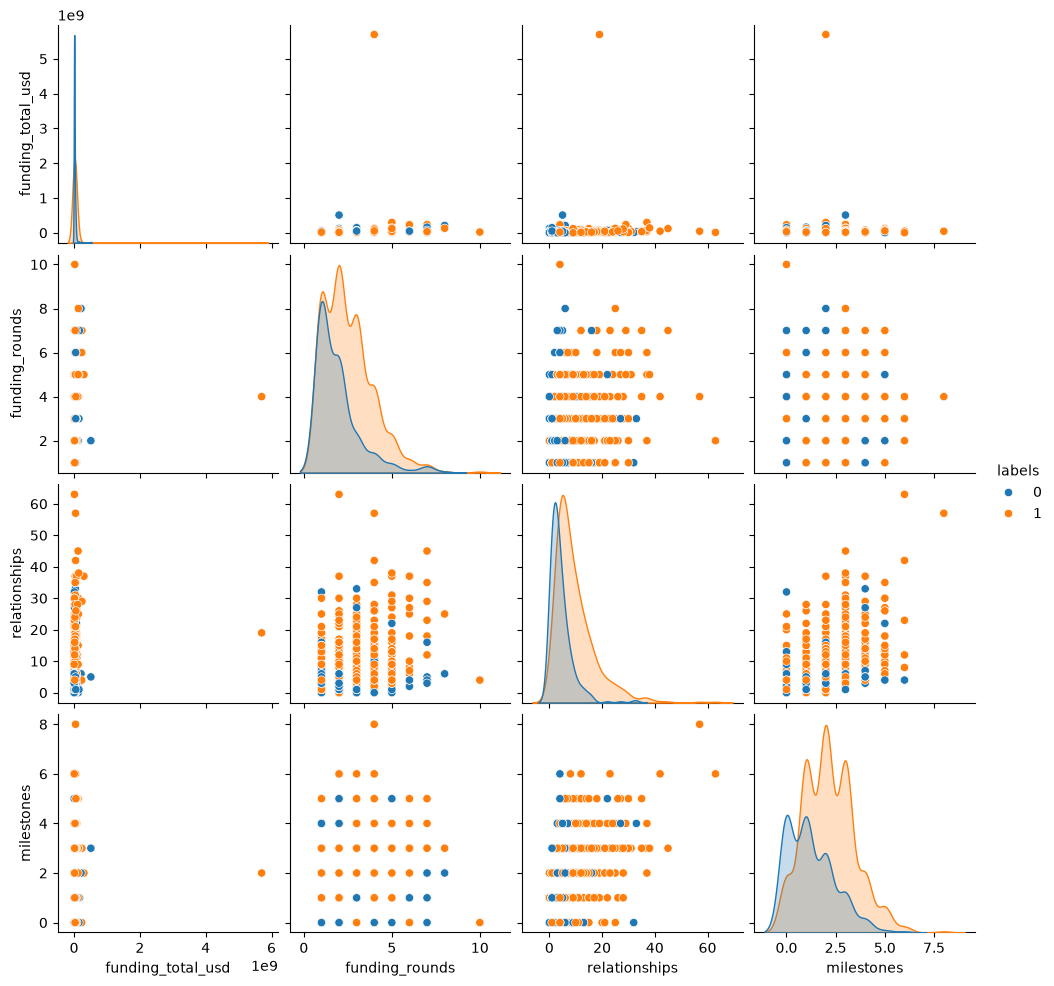

In [119]:
sample = df[
    [
        "funding_total_usd",
        "funding_rounds",
        "relationships",
        "milestones",
        "labels"
    ]
]

sns.pairplot(sample, hue="labels")

plt.show()

## EDA Summary

Key observations:

- The dataset contains both successful and failed startups.
- Funding distribution is highly skewed.
- Startup categories are unevenly distributed.
- Some numerical variables contain outliers.
- Venture capital funding appears positively associated with startup success.
- Companies with more milestones and investor participation tend to have higher success rates.
- Correlation analysis shows that funding, milestones, and relationships may be important predictors.

In [120]:
# Remove columns that do not help prediction

columns_to_remove = [
    "id",
    "object_id",
    "name",
    "zip_code",
    "city",
    "status"
]

df.drop(columns=columns_to_remove, inplace=True)

In [121]:
# Convert to datetime

date_columns = [
    "founded_at",
    "first_funding_at",
    "last_funding_at"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

In [122]:
# Extract year

df["founded_year"] = df["founded_at"].dt.year
df["first_funding_year"] = df["first_funding_at"].dt.year
df["last_funding_year"] = df["last_funding_at"].dt.year

In [123]:
df.drop(
    columns=[
        "founded_at",
        "first_funding_at",
        "last_funding_at"
    ],
    inplace=True
)

In [124]:
df.columns

Index(['state_code', 'latitude', 'longitude', 'labels',
       'age_first_funding_year', 'age_last_funding_year',
       'age_first_milestone_year', 'age_last_milestone_year', 'relationships',
       'funding_rounds', 'funding_total_usd', 'milestones', 'is_CA', 'is_NY',
       'is_MA', 'is_TX', 'is_otherstate', 'category_code', 'is_software',
       'is_web', 'is_mobile', 'is_enterprise', 'is_advertising',
       'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting',
       'is_othercategory', 'has_VC', 'has_angel', 'has_roundA', 'has_roundB',
       'has_roundC', 'has_roundD', 'avg_participants', 'is_top500',
       'founded_year', 'first_funding_year', 'last_funding_year'],
      dtype='str')

In [125]:
df.shape

(923, 39)

In [126]:
df_processed = df.copy()

In [127]:
df.head()

,state_code,latitude,longitude,labels,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,...,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,founded_year,first_funding_year,last_funding_year
0,CA,42.358880,-71.056820,1,2.2493,3.0027,4.6685,6.7041,3,3,...,1,0,0,0,0,1.0000,0,2007,2009,2010
1,CA,37.238916,-121.973718,1,5.1260,9.9973,7.0055,7.0055,9,4,...,0,0,1,1,1,4.7500,1,2000,2005,2009
2,CA,32.901049,-117.192656,1,1.0329,1.0329,1.4575,2.2055,5,1,...,0,1,0,0,0,4.0000,1,2009,2010,2010
3,CA,37.320309,-122.050040,1,3.1315,5.3151,6.0027,6.0027,5,3,...,0,0,1,1,1,3.3333,1,2002,2005,2007
4,CA,37.779281,-122.419236,0,0.0000,1.6685,0.0384,0.0384,2,2,...,1,0,0,0,0,1.0000,1,2010,2010,2012


In [128]:
# Display categorical columns

categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['state_code', 'category_code'], dtype='str')


In [129]:
# One-Hot Encode categorical columns

df = pd.get_dummies(
    df,
    columns=["state_code", "category_code"],
    drop_first=True
)

In [130]:
df.shape

(923, 105)

In [131]:
X = df.drop("labels", axis=1)

In [132]:
y = df["labels"]

In [133]:
print(X.shape)

print(y.shape)

(923, 104)
(923,)


In [134]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [135]:
import joblib

joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

## Encoding and Feature Scaling

The categorical variables were converted into numerical format using One-Hot Encoding.

The target variable (`labels`) was separated from the feature variables.

The numerical features were standardized using StandardScaler so that all features contribute equally during model training.

The fitted scaler was saved using Joblib for future use in the deployed Streamlit application.

**The dataset is divided into training and testing sets using an 80:20 ratio.**

A stratified split is used to preserve the class distribution of the target variable in both datasets.

In [136]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [137]:
print("Training Set Distribution")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Set Distribution")
print(y_test.value_counts(normalize=True) * 100)

Training Set Distribution
labels
1    64.634146
0    35.365854
Name: proportion, dtype: float64

Testing Set Distribution
labels
1    64.864865
0    35.135135
Name: proportion, dtype: float64


# Model 1 – Logistic Regression

Logistic Regression is used as the baseline classification model. It estimates the probability that a startup will succeed using the sigmoid function.

In [138]:
from sklearn.linear_model import LogisticRegression
# Train Logistic Regression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [139]:
y_pred_log = log_model.predict(X_test)

In [140]:
y_prob_log = log_model.predict_proba(X_test)[:,1]

In [141]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_log)

print("Accuracy :", accuracy)

Accuracy : 0.7297297297297297


In [142]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred_log)

print("Precision :", precision)

Precision : 0.8070175438596491


In [143]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred_log)

print("Recall :", recall)

Recall : 0.7666666666666667


In [144]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred_log)

print("F1 Score :", f1)

F1 Score : 0.7863247863247863


In [145]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, y_prob_log)

print("ROC-AUC :", roc)

ROC-AUC : 0.7741025641025641


In [146]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.61      0.66      0.63        65
           1       0.81      0.77      0.79       120

    accuracy                           0.73       185
   macro avg       0.71      0.71      0.71       185
weighted avg       0.74      0.73      0.73       185



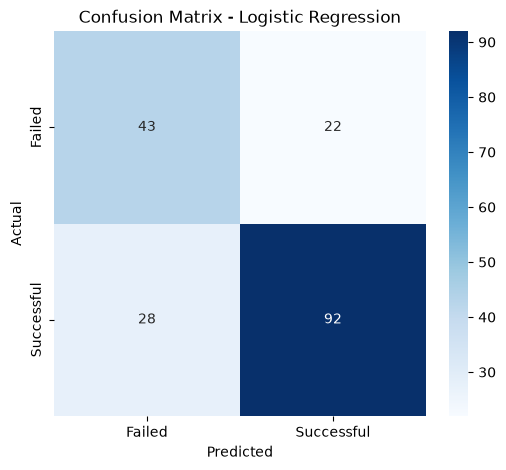

In [147]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Failed","Successful"],
    yticklabels=["Failed","Successful"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

### Logistic Regression Results

- Logistic Regression acts as the baseline model.
- It predicts startup success using a probabilistic approach.
- The confusion matrix shows the number of correctly and incorrectly classified startups.
- Performance will later be compared with Decision Tree, Random Forest, and XGBoost.

### Logistic Regression Analysis

The Logistic Regression model achieved an accuracy of **72.97%**, making it a good baseline classifier.

It achieved a **Precision of 80.70%**, indicating that most startups predicted as successful were actually successful.

The **Recall of 76.67%** shows that the model correctly identified a large proportion of successful startups.

The **F1 Score of 78.63%** demonstrates a good balance between precision and recall.

The **ROC-AUC score of 77.41%** indicates a good ability to distinguish between successful and failed startups.

In [148]:
model_results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
])

model_results.loc[len(model_results)] = [
    "Logistic Regression",
    round(accuracy,4),
    round(precision,4),
    round(recall,4),
    round(f1,4),
    round(roc,4)
]

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7297,0.807,0.7667,0.7863,0.7741


# Model 2 – Decision Tree Classifier

Decision Tree is a supervised machine learning algorithm used for classification and regression tasks. It predicts the target variable by learning simple decision rules inferred from the training data. Decision Trees are easy to interpret and can capture non-linear relationships between features.

In [149]:
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [150]:
# Predict labels

y_pred_dt = dt_model.predict(X_test)

In [151]:
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [152]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Accuracy :", accuracy_dt)
precision_dt = precision_score(y_test, y_pred_dt)
print("Precision :", precision_dt)
recall_dt = recall_score(y_test, y_pred_dt)
print("Recall :", recall_dt)
f1_dt = f1_score(y_test, y_pred_dt)
print("F1 Score :", f1_dt)
roc_dt = roc_auc_score(y_test, y_prob_dt)
print("ROC-AUC :", roc_dt)

Accuracy : 0.6864864864864865
Precision : 0.7924528301886793
Recall : 0.7
F1 Score : 0.7433628318584071
ROC-AUC : 0.6807692307692308


In [153]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.54      0.66      0.60        65
           1       0.79      0.70      0.74       120

    accuracy                           0.69       185
   macro avg       0.67      0.68      0.67       185
weighted avg       0.71      0.69      0.69       185



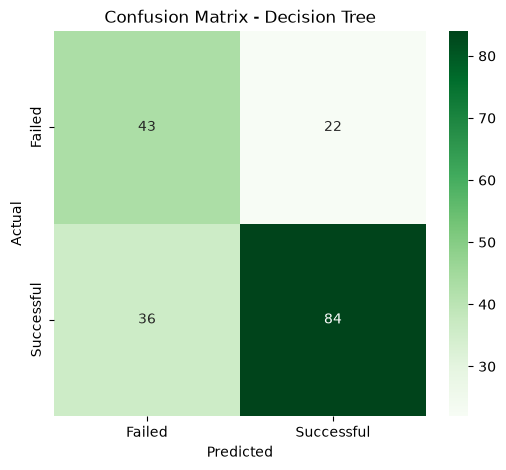

In [154]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Failed","Successful"],
    yticklabels=["Failed","Successful"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Decision Tree")

plt.show()

### Decision Tree Analysis

The Decision Tree model was trained on the startup dataset to classify startups as successful or failed.

The model captured non-linear relationships between startup characteristics and outcomes.

The evaluation metrics indicate its predictive performance, which will later be compared with Logistic Regression, Random Forest, and XGBoost to identify the best-performing model.

# Model 3 – Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting. It predicts the final class based on majority voting among all trees.

In [155]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [156]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [157]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy :", accuracy_rf)
precision_rf = precision_score(y_test, y_pred_rf)
print("Precision :", precision_rf)
recall_rf = recall_score(y_test, y_pred_rf)
print("Recall :", recall_rf)
f1_rf = f1_score(y_test, y_pred_rf)
print("F1 Score :", f1_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)
print("ROC-AUC :", roc_rf)

Accuracy : 0.8216216216216217
Precision : 0.8270676691729323
Recall : 0.9166666666666666
F1 Score : 0.8695652173913043
ROC-AUC : 0.8438461538461538


In [158]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.81      0.65      0.72        65
           1       0.83      0.92      0.87       120

    accuracy                           0.82       185
   macro avg       0.82      0.78      0.79       185
weighted avg       0.82      0.82      0.82       185



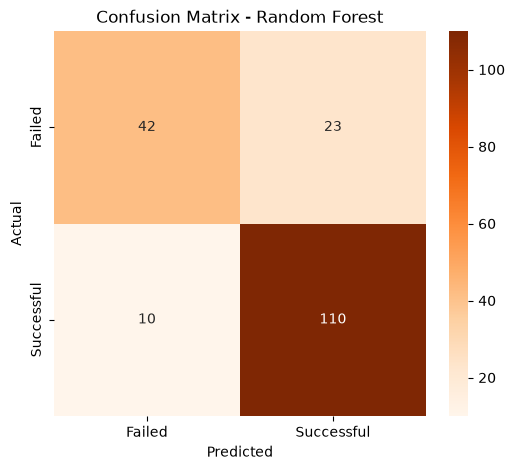

In [159]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Failed","Successful"],
    yticklabels=["Failed","Successful"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Random Forest")

plt.show()

In [160]:
model_results.loc[len(model_results)] = [
    "Random Forest",
    round(accuracy_rf,4),
    round(precision_rf,4),
    round(recall_rf,4),
    round(f1_rf,4),
    round(roc_rf,4)
]

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7297,0.8070,0.7667,0.7863,0.7741
1,Random Forest,0.8216,0.8271,0.9167,0.8696,0.8438


### Random Forest Analysis

Random Forest combines multiple Decision Trees using ensemble learning. It generally provides better accuracy and generalization than a single Decision Tree because it reduces overfitting through majority voting.

The evaluation metrics obtained from Random Forest will be compared with the other models to determine the best-performing classifier.

# Model 4 – XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm based on gradient boosting. It builds decision trees sequentially, where each new tree corrects the errors made by previous trees.

Advantages:
- High prediction accuracy
- Handles missing values efficiently
- Reduces overfitting through regularization
- Faster than many other boosting algorithms
- Provides feature importance

In [161]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [162]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [163]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("Accuracy :", accuracy_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
print("Precision :", precision_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
print("Recall :", recall_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
print("F1 Score :", f1_xgb)
roc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("ROC-AUC :", roc_xgb)

Accuracy : 0.7837837837837838
Precision : 0.8125
Recall : 0.8666666666666667
F1 Score : 0.8387096774193549
ROC-AUC : 0.8392307692307692


In [164]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.72      0.63      0.67        65
           1       0.81      0.87      0.84       120

    accuracy                           0.78       185
   macro avg       0.77      0.75      0.76       185
weighted avg       0.78      0.78      0.78       185



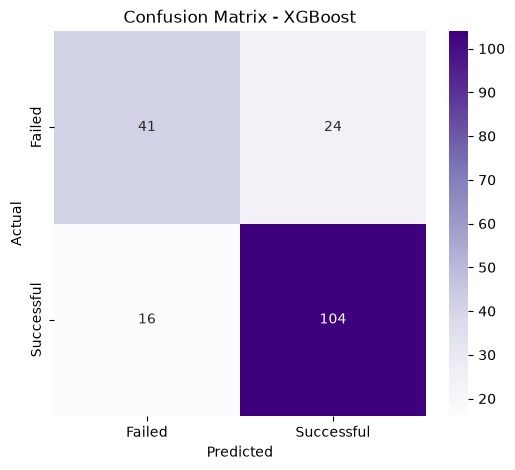

In [165]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Failed", "Successful"],
    yticklabels=["Failed", "Successful"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

In [166]:
model_results.loc[len(model_results)] = [
    "XGBoost",
    round(accuracy_xgb,4),
    round(precision_xgb,4),
    round(recall_xgb,4),
    round(f1_xgb,4),
    round(roc_xgb,4)
]

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7297,0.8070,0.7667,0.7863,0.7741
1,Random Forest,0.8216,0.8271,0.9167,0.8696,0.8438
2,XGBoost,0.7838,0.8125,0.8667,0.8387,0.8392


# Model Comparison

Four machine learning algorithms were trained and evaluated for startup success prediction:

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|--------|---------:|----------:|-------:|---------:|---------:|
| Logistic Regression | 72.97% | 80.70% | 76.67% | 78.63% | 77.41% |
| Decision Tree | 68.65% | 79.25% | 70.00% | 74.34% | 68.08% |
| Random Forest | 82.16% | 82.71% | 91.67% | 86.96% | 84.38% |
| XGBoost | 78.38% | 81.25% | 86.67% | 83.87% | 83.92% |

Among all the models, **Random Forest** achieved the highest overall performance and was selected as the final model for deployment.

In [167]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
6,relationships,0.122825
5,age_last_milestone_year,0.083333
8,funding_total_usd,0.073677
9,milestones,0.064069
4,age_first_milestone_year,0.057153
31,avg_participants,0.056511
3,age_last_funding_year,0.055142
2,age_first_funding_year,0.052870
33,founded_year,0.041551
1,longitude,0.040191


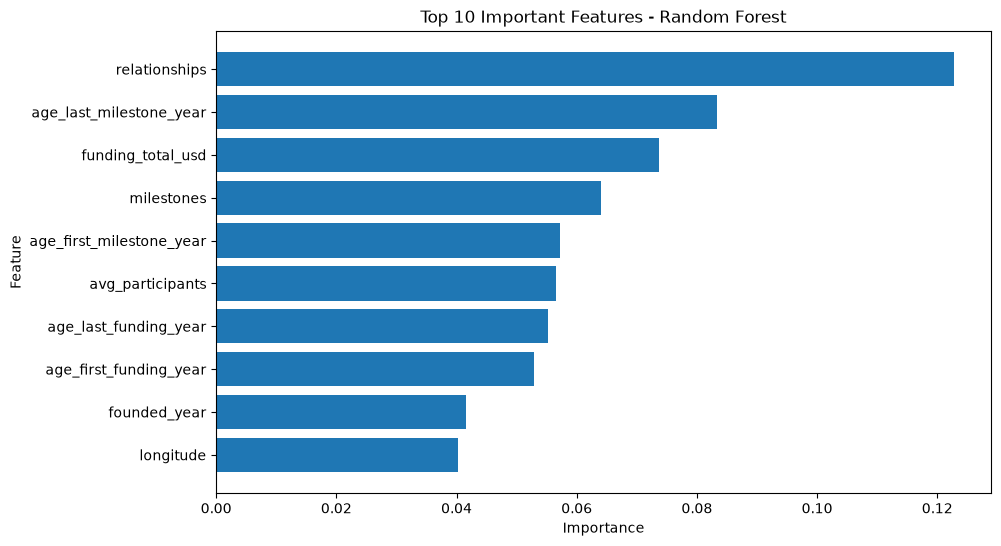

In [168]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top 10 Important Features - Random Forest")

plt.gca().invert_yaxis()

plt.show()

### Feature Importance Analysis

Random Forest provides feature importance scores that indicate the influence of each feature on the prediction.

The plot shows the ten most important features contributing to startup success prediction. These insights help understand which startup characteristics have the greatest impact on the model's decisions.

In [169]:
import joblib

joblib.dump(rf_model, "../models/best_model.pkl")

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [170]:
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

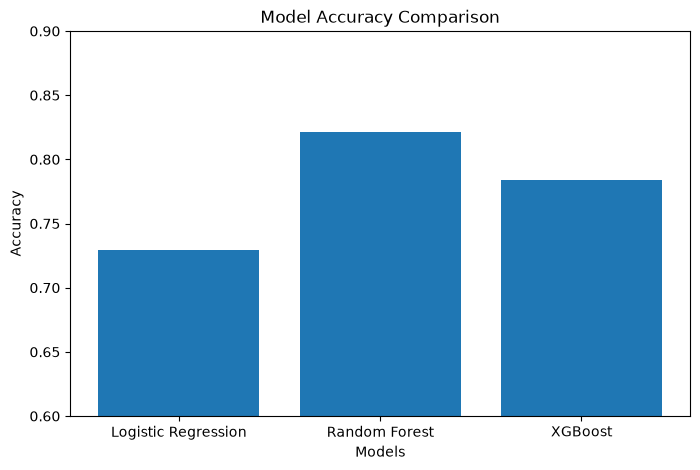

In [171]:
plt.figure(figsize=(8,5))

plt.bar(
    model_results["Model"],
    model_results["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0.6, 0.9)

plt.show()

# Conclusion

This project developed a machine learning system to predict startup success using historical startup data.

Four classification algorithms were evaluated:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Among them, Random Forest achieved the best performance with an accuracy of **82.16%**, making it the most suitable model for deployment.

The trained model can assist investors, entrepreneurs, and analysts in estimating the likelihood of startup success based on key business characteristics.

In [172]:
import streamlit as st
import pandas as pd
import joblib

In [173]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(rf_model, "models/best_model.pkl")

['models/best_model.pkl']

In [174]:
model = joblib.load("models/best_model.pkl")
scaler = joblib.load("models/scaler.pkl")

In [175]:
feature_names = X.columns.tolist()

print(feature_names)

['latitude', 'longitude', 'age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year', 'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones', 'is_CA', 'is_NY', 'is_MA', 'is_TX', 'is_otherstate', 'is_software', 'is_web', 'is_mobile', 'is_enterprise', 'is_advertising', 'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting', 'is_othercategory', 'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'has_roundD', 'avg_participants', 'is_top500', 'founded_year', 'first_funding_year', 'last_funding_year', 'state_code_AZ', 'state_code_CA', 'state_code_CO', 'state_code_CT', 'state_code_DC', 'state_code_FL', 'state_code_GA', 'state_code_ID', 'state_code_IL', 'state_code_IN', 'state_code_KY', 'state_code_MA', 'state_code_MD', 'state_code_ME', 'state_code_MI', 'state_code_MN', 'state_code_MO', 'state_code_NC', 'state_code_NH', 'state_code_NJ', 'state_code_NM', 'state_code_NV', 'state_code_NY', 'state_code_OH', 'state_co

In [176]:
pd.DataFrame({"Feature": X.columns}).to_csv("feature_names.csv", index=False)

In [177]:
st.header("Startup Information")

latitude = st.number_input("Latitude", value=37.77)

longitude = st.number_input("Longitude", value=-122.41)

funding_total_usd = st.number_input(
    "Total Funding (USD)",
    min_value=0.0,
    value=1000000.0
)

funding_rounds = st.number_input(
    "Funding Rounds",
    min_value=0,
    value=1
)

relationships = st.number_input(
    "Relationships",
    min_value=0,
    value=5
)

milestones = st.number_input(
    "Milestones",
    min_value=0,
    value=2
)

avg_participants = st.number_input(
    "Average Participants",
    min_value=0,
    value=2
)

2026-07-30 23:55:57.448 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.482 
  command:

    streamlit run c:\Users\Gadkol Saijeshwanth\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-30 23:55:57.484 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.485 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.486 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.486 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.487 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
202

In [178]:
st.subheader("Timeline")

founded_year = st.number_input(
    "Founded Year",
    min_value=1980,
    max_value=2030,
    value=2015
)

first_funding_year = st.number_input(
    "First Funding Year",
    min_value=1980,
    max_value=2035,
    value=2016
)

last_funding_year = st.number_input(
    "Last Funding Year",
    min_value=1980,
    max_value=2035,
    value=2018
)

age_first_funding_year = first_funding_year - founded_year

age_last_funding_year = last_funding_year - founded_year

age_first_milestone_year = st.number_input(
    "Age at First Milestone",
    min_value=0.0,
    value=1.0
)

age_last_milestone_year = st.number_input(
    "Age at Last Milestone",
    min_value=0.0,
    value=3.0
)

2026-07-30 23:55:57.534 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.536 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.537 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.538 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.540 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [179]:
has_VC = st.checkbox("Has Venture Capital")

has_angel = st.checkbox("Has Angel Investment")

has_roundA = st.checkbox("Has Round A")

has_roundB = st.checkbox("Has Round B")

has_roundC = st.checkbox("Has Round C")

has_roundD = st.checkbox("Has Round D")

is_top500 = st.checkbox("Top 500 Startup")

2026-07-30 23:55:57.577 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.578 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.579 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.579 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.580 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.581 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.582 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.582 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [180]:
state = st.selectbox(
    "State",
    [
        "AZ","CA","CO","CT","DC","FL","GA","ID",
        "IL","IN","KY","MA","MD","ME","MI","MN",
        "MO","NC","NH","NJ","NM","NV","NY","OH",
        "OR","PA","RI","TN","TX","UT","VA","WA",
        "WI","WV"
    ]
)

2026-07-30 23:55:57.615 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.615 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.616 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.617 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.618 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.619 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [181]:
category = st.selectbox(
    "Category",
    [
        "analytics",
        "automotive",
        "biotech",
        "cleantech",
        "consulting",
        "ecommerce",
        "education",
        "enterprise",
        "fashion",
        "finance",
        "games_video",
        "hardware",
        "health",
        "hospitality",
        "manufacturing",
        "medical",
        "messaging",
        "mobile",
        "music",
        "network_hosting",
        "news",
        "other",
        "photo_video",
        "public_relations",
        "real_estate",
        "search",
        "security",
        "semiconductor",
        "social",
        "software",
        "sports",
        "transportation",
        "travel",
        "web"
    ]
)

2026-07-30 23:55:57.629 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.630 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.630 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.631 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.632 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:55:57.633 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [182]:
print(df.columns.tolist())

['latitude', 'longitude', 'labels', 'age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year', 'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones', 'is_CA', 'is_NY', 'is_MA', 'is_TX', 'is_otherstate', 'is_software', 'is_web', 'is_mobile', 'is_enterprise', 'is_advertising', 'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting', 'is_othercategory', 'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'has_roundD', 'avg_participants', 'is_top500', 'founded_year', 'first_funding_year', 'last_funding_year', 'state_code_AZ', 'state_code_CA', 'state_code_CO', 'state_code_CT', 'state_code_DC', 'state_code_FL', 'state_code_GA', 'state_code_ID', 'state_code_IL', 'state_code_IN', 'state_code_KY', 'state_code_MA', 'state_code_MD', 'state_code_ME', 'state_code_MI', 'state_code_MN', 'state_code_MO', 'state_code_NC', 'state_code_NH', 'state_code_NJ', 'state_code_NM', 'state_code_NV', 'state_code_NY', 'state_code_OH',

In [183]:
print(len(X.columns))
print(X.columns.tolist())

104
['latitude', 'longitude', 'age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year', 'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones', 'is_CA', 'is_NY', 'is_MA', 'is_TX', 'is_otherstate', 'is_software', 'is_web', 'is_mobile', 'is_enterprise', 'is_advertising', 'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting', 'is_othercategory', 'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'has_roundD', 'avg_participants', 'is_top500', 'founded_year', 'first_funding_year', 'last_funding_year', 'state_code_AZ', 'state_code_CA', 'state_code_CO', 'state_code_CT', 'state_code_DC', 'state_code_FL', 'state_code_GA', 'state_code_ID', 'state_code_IL', 'state_code_IN', 'state_code_KY', 'state_code_MA', 'state_code_MD', 'state_code_ME', 'state_code_MI', 'state_code_MN', 'state_code_MO', 'state_code_NC', 'state_code_NH', 'state_code_NJ', 'state_code_NM', 'state_code_NV', 'state_code_NY', 'state_code_OH', 'stat